# 07. Tree-Based Anomaly Detection: Isolation Forest

The previous notebooks studied statistical, distance-based, and density-based anomaly detection. Isolation Forest takes a different route: it does not estimate a mean, covariance, distance distribution, or density. Instead, it asks how quickly a point can be separated from the rest of the data by random tree splits.

The core intuition is simple. Anomalies tend to be **few and different**. If a point is unusual, random splits often isolate it after only a small number of tree decisions. Normal points, surrounded by many similar cases, usually require longer paths through the tree.

This makes Isolation Forest attractive for industry monitoring:

1. It handles nonlinear feature interactions better than single-variable thresholds.
2. It scales well to large tabular datasets.
3. It produces a ranked anomaly score that can be turned into a review queue.
4. It does not require labeled anomalies to train.

The decision-science theme is that tree-based anomaly scores are useful operational signals, but they still need threshold design, sensitivity analysis, feature diagnostics, segment monitoring, and human review.

## Learning Objectives

By the end of this lecture, you should be able to:

1. Explain why isolation can be used as an anomaly detection principle.
2. Define path length and the Isolation Forest anomaly score.
3. Distinguish Isolation Forest from distance and density methods.
4. Fit Isolation Forest on a realistic operational monitoring dataset.
5. Compare raw and transformed feature representations.
6. Tune review budgets, `max_samples`, and number of trees from a decision perspective.
7. Build practical feature diagnostics for tree-based anomaly scores.
8. Translate Isolation Forest results into a launch memo with caveats and monitoring rules.

In [1]:
# Section focus: Learning Objectives.
# The code groups setup, estimation, and diagnostics so the output can be rerun reproducibly.

import sys
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.ensemble import IsolationForest
from sklearn.metrics import average_precision_score, precision_recall_curve, roc_auc_score
from sklearn.neighbors import NearestNeighbors
from sklearn.preprocessing import StandardScaler

repo_root = next(path for path in [Path.cwd(), *Path.cwd().parents] if (path / 'notebooks' / '_shared' / 'display.py').exists())
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

from notebooks._shared.display import smart_display

warnings.filterwarnings('ignore', category=FutureWarning)
warnings.filterwarnings('ignore', category=UserWarning)

sns.set_theme(style='whitegrid', context='notebook')
RANDOM_SEED = 11

PALETTE = {
    'normal_web': '#9aaec1',
    'normal_batch': '#6fb7a8',
    'memory_leak': '#d95f5f',
    'network_saturation': '#f28e2b',
    'crash_loop': '#8b6fd6',
    'diagonal_degradation': '#c27ba0',
    'alert': '#7b61ff',
    'decision': '#1f6f64',
}

## 1. Isolation as a Model of Unusualness

Let $x_i \in \mathbb{R}^p$ be an operational feature vector. An isolation tree recursively partitions the feature space by selecting:

1. a feature $j$ at random, and
2. a split point uniformly between the observed minimum and maximum of that feature inside the current node.

The path length $h(x_i)$ is the number of splits needed before $x_i$ is isolated or the tree reaches a stopping rule.

Anomalies are expected to have shorter path lengths because they occupy sparse or extreme regions. Isolation Forest averages path lengths over many random trees:

$$
E[h(x_i)] = \frac{1}{T}\sum_{t=1}^{T} h_t(x_i),
$$

where $T$ is the number of trees.

The original Isolation Forest score normalizes the expected path length by the average path length of unsuccessful search in a binary search tree:

$$
s(x_i, \psi) = 2^{-E[h(x_i)] / c(\psi)},
$$

where $\psi$ is the subsample size and

$$
c(\psi) = 2H_{\psi-1} - \frac{2(\psi-1)}{\psi}.
$$

Here $H_m$ is the $m$th harmonic number. Scores closer to 1 are more anomalous; scores much smaller than 0.5 are more normal. In scikit-learn, `score_samples` uses the opposite convention: lower values are more abnormal. In this notebook, we use

$$
S_i = -\texttt{score\_samples}(x_i),
$$

so larger values mean more suspicious cases.

## 2. Why Isolation Forest Is Different

Many anomaly detectors first model normality. Isolation Forest tries to isolate anomalies directly. That distinction affects how we use it.

| Method family | Core question | Common risk |
|---|---|---|
| Statistical detectors | Is the point far from a fitted center or distribution? | Miss nonlinear or multi-regime structure |
| Distance methods | Are the nearest neighbors far away? | Sensitive to scaling and sparse normal regimes |
| Density methods | Is the estimated density low? | Sensitive to bandwidth, radius, and dimension |
| Isolation Forest | How quickly can random splits isolate the point? | Sensitive to feature representation, subsampling, and axis-aligned splits |

Isolation Forest is often robust and fast, but it is not magic. Standard Isolation Forest uses axis-aligned splits. Extended Isolation Forest generalizes this idea to random hyperplane cuts, partly to reduce artifacts from axis-aligned partitioning (Hariri et al., 2021).

## 3. Synthetic Case: Cloud Operations Monitoring

Imagine a platform reliability team monitoring service-period summaries from production infrastructure. The data contain two legitimate normal regimes:

| Regime | Description |
|---|---|
| `normal_web` | User-facing services with high request rates and moderate latency |
| `normal_batch` | Batch-processing jobs with higher CPU and disk activity but lower request rates |

The team wants to detect service periods that require operational review. Some anomalies are obvious, such as crash loops. Others involve combinations of moderately unusual values that are not extreme one variable at a time.

The review question is: **can a tree-based isolation score identify risky infrastructure periods while avoiding systematic over-alerting of legitimate batch jobs?**

In [2]:
def simulate_cloud_operations(n_web=2800, n_batch=850, n_anomaly=260, seed=RANDOM_SEED):
    """Create a simulated cloud operations data set for the 07. Tree-Based Anomaly Detection: Isolation Forest case study.
    
    Parameters
    ----------
    n_web : object
        Count or size setting for the cloud operations calculation.
    n_batch : object
        Count or size setting for the cloud operations calculation.
    n_anomaly : object
        Count or size setting for the cloud operations calculation.
    seed : object
        Random seed used to make the simulation reproducible.
    
    Returns
    -------
    object
        Tuple of outputs from this workflow, usually data, fitted objects, or diagnostics used by later cells.
    """
    rng = np.random.default_rng(seed)
    feature_cols = [
        'cpu_pct',
        'memory_pct',
        'disk_io_mb_s',
        'network_out_mb_s',
        'p95_latency_ms',
        'error_rate_pct',
        'restart_count',
        'request_rate',
    ]

    # Normal web services.
    req_w = np.clip(rng.normal(900, 150, n_web), 250, None)
    cpu_w = np.clip(22 + 0.035 * req_w + rng.normal(0, 7, n_web), 2, 98)
    mem_w = np.clip(48 + 0.012 * req_w + rng.normal(0, 7, n_web), 5, 98)
    disk_w = np.clip(rng.lognormal(np.log(85), 0.35, n_web), 5, None)
    net_w = np.clip(0.10 * req_w + rng.normal(0, 18, n_web), 2, None)
    lat_w = np.clip(155 + 0.08 * cpu_w + 0.035 * req_w + rng.normal(0, 28, n_web), 20, None)
    err_w = np.clip(rng.gamma(2.0, 0.12, n_web) + 0.0015 * (lat_w - 180).clip(0), 0, 8)
    rest_w = np.clip(rng.poisson(0.12, n_web), 0, None)
    web = np.column_stack([cpu_w, mem_w, disk_w, net_w, lat_w, err_w, rest_w, req_w])

    # Normal batch jobs: legitimate but less like web-service traffic.
    req_b = np.clip(rng.normal(260, 55, n_batch), 30, None)
    cpu_b = np.clip(rng.normal(72, 9, n_batch), 5, 99)
    mem_b = np.clip(rng.normal(68, 10, n_batch), 5, 99)
    disk_b = np.clip(rng.lognormal(np.log(260), 0.42, n_batch), 10, None)
    net_b = np.clip(rng.lognormal(np.log(42), 0.50, n_batch), 2, None)
    lat_b = np.clip(260 + 0.9 * cpu_b + rng.normal(0, 55, n_batch), 40, None)
    err_b = np.clip(rng.gamma(1.8, 0.10, n_batch), 0, 8)
    rest_b = np.clip(rng.poisson(0.18, n_batch), 0, None)
    batch = np.column_stack([cpu_b, mem_b, disk_b, net_b, lat_b, err_b, rest_b, req_b])

    # Failure modes.
    n1 = int(0.35 * n_anomaly)
    n2 = int(0.30 * n_anomaly)
    n3 = int(0.22 * n_anomaly)
    n4 = n_anomaly - n1 - n2 - n3

    # Memory leak: high memory, high latency, elevated errors.
    req = np.clip(rng.normal(820, 160, n1), 250, None)
    leak = np.column_stack([
        np.clip(rng.normal(60, 10, n1), 2, 99),
        np.clip(rng.normal(96, 3, n1), 50, 100),
        np.clip(rng.lognormal(np.log(110), 0.35, n1), 5, None),
        np.clip(0.11 * req + rng.normal(0, 20, n1), 2, None),
        np.clip(rng.normal(520, 90, n1), 60, None),
        np.clip(rng.normal(2.8, 0.8, n1), 0, 12),
        np.clip(rng.poisson(0.8, n1), 0, None),
        req,
    ])

    # Network saturation: traffic and latency spike together.
    req = np.clip(rng.normal(980, 140, n2), 250, None)
    net_sat = np.column_stack([
        np.clip(rng.normal(67, 8, n2), 2, 99),
        np.clip(rng.normal(66, 8, n2), 5, 99),
        np.clip(rng.lognormal(np.log(100), 0.40, n2), 5, None),
        np.clip(rng.normal(260, 45, n2), 20, None),
        np.clip(rng.normal(650, 110, n2), 80, None),
        np.clip(rng.normal(1.8, 0.5, n2), 0, 10),
        np.clip(rng.poisson(0.25, n2), 0, None),
        req,
    ])

    # Crash loop: restarts and errors rise while traffic drops.
    crash = np.column_stack([
        np.clip(rng.normal(38, 10, n3), 2, 99),
        np.clip(rng.normal(45, 12, n3), 5, 99),
        np.clip(rng.lognormal(np.log(55), 0.45, n3), 5, None),
        np.clip(rng.normal(35, 16, n3), 2, None),
        np.clip(rng.normal(430, 100, n3), 50, None),
        np.clip(rng.normal(7.5, 1.4, n3), 0, 15),
        np.clip(rng.poisson(7, n3), 0, None),
        np.clip(rng.normal(420, 90, n3), 30, None),
    ])

    # Diagonal degradation: not always extreme on one variable, but unusual jointly.
    diag = np.column_stack([
        np.clip(rng.normal(78, 5, n4), 2, 99),
        np.clip(rng.normal(84, 5, n4), 5, 99),
        np.clip(rng.lognormal(np.log(190), 0.20, n4), 5, None),
        np.clip(rng.normal(120, 25, n4), 2, None),
        np.clip(rng.normal(455, 50, n4), 60, None),
        np.clip(rng.normal(1.2, 0.35, n4), 0, 10),
        np.clip(rng.poisson(0.6, n4), 0, None),
        np.clip(rng.normal(650, 80, n4), 150, None),
    ])

    X = np.vstack([web, batch, leak, net_sat, crash, diag])
    df = pd.DataFrame(X, columns=feature_cols)
    df['regime'] = (
        ['normal_web'] * n_web
        + ['normal_batch'] * n_batch
        + ['memory_leak'] * n1
        + ['network_saturation'] * n2
        + ['crash_loop'] * n3
        + ['diagonal_degradation'] * n4
    )
    df['known_anomaly'] = (~df['regime'].str.startswith('normal')).astype(int)
    df['review_minutes'] = np.where(
        df['known_anomaly'].eq(1),
        rng.normal(38, 9, len(df)),
        rng.normal(13, 4, len(df)),
    ).clip(5, 70)
    return df, feature_cols

ops_df, feature_cols = simulate_cloud_operations()
summary = pd.DataFrame({
    'Quantity': [
        'Service-period records',
        'Known anomaly rate',
        'Normal web periods',
        'Normal batch periods',
        'Features used by Isolation Forest',
        'Median review minutes',
    ],
    'Value': [
        f'{len(ops_df):,}',
        f'{ops_df["known_anomaly"].mean():.1%}',
        f'{ops_df["regime"].eq("normal_web").sum():,}',
        f'{ops_df["regime"].eq("normal_batch").sum():,}',
        f'{len(feature_cols)}',
        f'{ops_df["review_minutes"].median():.1f}',
    ],
})

smart_display(ops_df.head())
smart_display(summary)
smart_display(ops_df['regime'].value_counts().rename_axis('service_period_type').reset_index(name='count'))

,cpu_pct,memory_pct,disk_io_mb_s,network_out_mb_s,p95_latency_ms,error_rate_pct,restart_count,request_rate,regime,known_anomaly,review_minutes
0,52.368084,55.000258,118.556939,41.861757,199.334792,0.487489,0.0,905.128915,normal_web,0,8.077858
1,67.408060,50.151128,68.948345,89.137636,177.017418,0.343535,1.0,1103.962131,normal_web,0,11.101418
2,57.772709,50.490084,56.864361,101.036770,189.322442,0.251519,0.0,1083.708162,normal_web,0,20.614639
3,43.085983,53.528552,93.119144,84.936076,182.309324,0.076326,0.0,823.453938,normal_web,0,8.759094
4,46.609751,53.477448,68.530567,116.439930,181.241293,0.242822,0.0,855.304573,normal_web,0,15.724058


,Quantity,Value
0,Service-period records,"3,910"
1,Known anomaly rate,6.6%
2,Normal web periods,"2,800"
3,Normal batch periods,850
4,Features used by Isolation Forest,8
5,Median review minutes,13.3


,service_period_type,count
0,normal_web,2800
1,normal_batch,850
2,memory_leak,91
3,network_saturation,78
4,crash_loop,57
5,diagonal_degradation,34


This case includes two normal operating regimes and four failure modes. The batch regime is legitimate but structurally different from web traffic. A detector that over-alerts batch jobs would create alert fatigue and erode trust.

The simulated known labels let us evaluate the teaching example. In real deployments, these labels would come from incident investigations, expert review, delayed outcomes, or staged pilots rather than being known at model training time.

## 4. Visual Orientation

We use PCA only for visualization. Isolation Forest will use the original tabular features. The point of the projection is to see whether alerts fall in plausible failure regions or whether they concentrate in a legitimate operating regime.

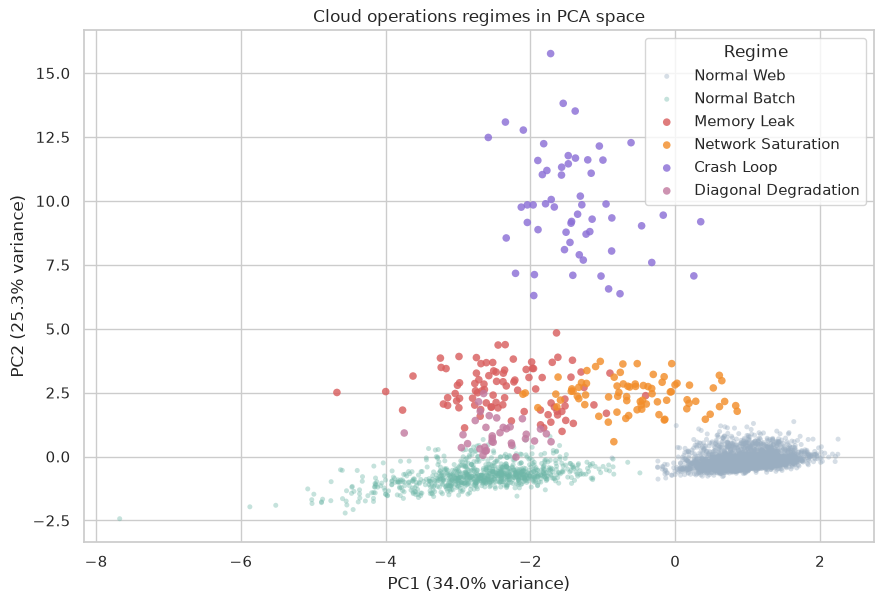

In [3]:
# Section focus: 4. Visual Orientation.
# The code below keeps the calculation explicit so each intermediate step can be inspected.

scaled_for_plot = StandardScaler().fit_transform(ops_df[feature_cols])
pca = PCA(n_components=2, random_state=RANDOM_SEED)
pc = pca.fit_transform(scaled_for_plot)
ops_df['pc1'] = pc[:, 0]
ops_df['pc2'] = pc[:, 1]

plot_order = ['normal_web', 'normal_batch', 'memory_leak', 'network_saturation', 'crash_loop', 'diagonal_degradation']
fig, ax = plt.subplots(figsize=(9.0, 6.2))
for regime in plot_order:
    subset = ops_df[ops_df['regime'].eq(regime)]
    is_normal = regime.startswith('normal')
    ax.scatter(
        subset['pc1'], subset['pc2'],
        s=13 if is_normal else 30,
        alpha=0.40 if is_normal else 0.82,
        color=PALETTE[regime],
        label=regime.replace('_', ' ').title(),
        edgecolor='none',
    )
ax.set_title('Cloud operations regimes in PCA space')
ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%} variance)')
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%} variance)')
ax.legend(title='Regime', loc='best', frameon=True)
plt.tight_layout()
plt.show()

The PCA view shows that some failure modes are separated from normal operation, while the diagonal degradation cases sit closer to the boundary of ordinary behavior. That is a realistic difficulty: not every anomaly is an obvious extreme point.

Visual Orientation should be read as an operations question. Ask whether the score isolates a real review priority or mostly reflects routine variation and noise.


## 5. Feature Representation: Raw Versus Transformed

Tree-based methods do not use Euclidean distance, so they are less directly affected by feature scaling than kNN, KDE, or DBSCAN. However, feature representation still matters.

A log transform can reduce the dominance of heavy-tailed operational counters. That may help when extreme raw values are mostly noise. It may hurt when the extremes are exactly the signal the risk team wants to preserve.

We will compare two representations:

| Representation | Description | Reason to test |
|---|---|---|
| Raw operational features | Original units such as percent, milliseconds, counts, and request rate | Preserves operational extremes |
| Log-transformed counters | Log transform for skewed count/rate/latency variables | Reduces heavy-tail dominance |

In [4]:
# Section focus: 5. Feature Representation: Raw Versus Transformed.
# The code groups setup, estimation, and diagnostics so the output can be rerun reproducibly.

log_transform_cols = [
    'disk_io_mb_s',
    'network_out_mb_s',
    'p95_latency_ms',
    'error_rate_pct',
    'restart_count',
    'request_rate',
]

PRETTY_FEATURE_NAMES = {
    'cpu_pct': 'CPU (%)',
    'memory_pct': 'Memory (%)',
    'disk_io_mb_s': 'Disk IO (MB/s)',
    'network_out_mb_s': 'Network Out (MB/s)',
    'p95_latency_ms': 'P95 Latency (ms)',
    'error_rate_pct': 'Error Rate (%)',
    'restart_count': 'Restart Count',
    'request_rate': 'Request Rate',
}

def make_log_representation(df):
    """Construct the log representation helper used in the 07. Tree-Based Anomaly Detection: Isolation Forest workflow.
    
    Parameters
    ----------
    df : object
        Input data frame containing the rows used in this notebook example.
    
    Returns
    -------
    object
        Tuple of outputs from this workflow, usually data, fitted objects, or diagnostics used by later cells.
    """
    transformed = pd.DataFrame(index=df.index)
    display_names = {}
    for col in feature_cols:
        if col in log_transform_cols:
            new_col = f'log_{col}'
            transformed[new_col] = np.log1p(df[col])
            display_names[new_col] = f'Log {PRETTY_FEATURE_NAMES[col]}'
        else:
            transformed[col] = df[col]
            display_names[col] = PRETTY_FEATURE_NAMES[col]
    return transformed, display_names

X_raw = ops_df[feature_cols].copy()
X_log, log_display_names = make_log_representation(ops_df)
raw_display_names = PRETTY_FEATURE_NAMES.copy()

review_budget = 0.05

def fit_isolation_forest(X, contamination=review_budget, max_samples=256, n_estimators=300, random_state=RANDOM_SEED):
    """Fit the isolation forest model or object used in the 07. Tree-Based Anomaly Detection: Isolation Forest analysis.
    
    Parameters
    ----------
    X : object
        Feature matrix used for fitting, prediction, or diagnostics.
    contamination : object
        The contamination setting that controls the isolation forest calculation in this notebook.
    max_samples : object
        The max samples setting that controls the isolation forest calculation in this notebook.
    n_estimators : object
        Count or size setting for the isolation forest calculation.
    random_state : object
        Random seed or generator control used to make results reproducible.
    
    Returns
    -------
    object
        Tuple of outputs from this workflow, usually data, fitted objects, or diagnostics used by later cells.
    """
    model = IsolationForest(
        n_estimators=n_estimators,
        max_samples=max_samples,
        contamination=contamination,
        random_state=random_state,
        n_jobs=-1,
    )
    model.fit(X)
    score = -model.score_samples(X)
    return model, score

def evaluate_alerts(score, alert, name):
    """Evaluate alerts for the 07. Tree-Based Anomaly Detection: Isolation Forest decision workflow.
    
    Parameters
    ----------
    score : object
        Single score, risk value, or diagnostic value used by the decision rule.
    alert : object
        The alert setting that controls the alerts calculation in this notebook.
    name : object
        Readable name used to label a model, variable, scenario, or diagnostic object.
    
    Returns
    -------
    object
        Dictionary or table of metrics used to compare model behavior.
    """
    alert = np.asarray(alert, dtype=bool)
    y = ops_df['known_anomaly'].to_numpy().astype(bool)
    false_alert_mask = alert & ~y
    return {
        'detector': name,
        'alerts': int(alert.sum()),
        'alert_rate': alert.mean(),
        'precision': y[alert].mean() if alert.sum() else np.nan,
        'recall': (alert & y).sum() / y.sum(),
        'false_positive_rate': false_alert_mask.sum() / (~y).sum(),
        'false_alerts': int(false_alert_mask.sum()),
        'average_precision': average_precision_score(y, score),
        'roc_auc': roc_auc_score(y, score),
        'normal_batch_share_of_false_alerts': ops_df.loc[false_alert_mask, 'regime'].eq('normal_batch').mean() if false_alert_mask.sum() else 0,
        'workload_hours': ops_df.loc[alert, 'review_minutes'].sum() / 60,
    }

model_specs = {
    'Raw features': (X_raw, raw_display_names),
    'Log-transformed counters': (X_log, log_display_names),
}

model_results = []
fitted_models = {}
for name, (X, display_names) in model_specs.items():
    model, score = fit_isolation_forest(X)
    cutoff = np.quantile(score, 1 - review_budget)
    alert = score >= cutoff
    row = evaluate_alerts(score, alert, name)
    row['cutoff_top_5_percent'] = cutoff
    model_results.append(row)
    fitted_models[name] = {
        'model': model,
        'score': score,
        'cutoff': cutoff,
        'alert': alert,
        'X': X,
        'display_names': display_names,
    }

model_table = pd.DataFrame(model_results)
model_table = model_table[[
    'detector', 'cutoff_top_5_percent', 'alerts', 'alert_rate', 'precision', 'recall',
    'false_positive_rate', 'false_alerts', 'average_precision', 'roc_auc', 'normal_batch_share_of_false_alerts', 'workload_hours'
]]
smart_display(model_table.style.format({
    'cutoff_top_5_percent': '{:.3f}',
    'alert_rate': '{:.1%}',
    'precision': '{:.1%}',
    'recall': '{:.1%}',
    'false_positive_rate': '{:.2%}',
    'average_precision': '{:.1%}',
    'roc_auc': '{:.3f}',
    'normal_batch_share_of_false_alerts': '{:.1%}',
    'workload_hours': '{:.1f}',
}))

,detector,cutoff_top_5_percent,alerts,alert_rate,precision,recall,false_positive_rate,false_alerts,average_precision,roc_auc,normal_batch_share_of_false_alerts,workload_hours
0,Raw features,0.578,196,5.0%,97.4%,73.5%,0.14%,5,97.1%,0.998,100.0%,123.3
1,Log-transformed counters,0.571,196,5.0%,87.2%,65.8%,0.68%,25,91.5%,0.994,96.0%,114.7


This comparison is deliberately empirical. It would be easy to say, "log-transform skewed variables," as a generic preprocessing rule. The table asks whether that rule actually improves the review queue.

For tree-based isolation, preserving raw operational extremes can be useful. If high latency, restart count, or network output are genuine risk signals, compressing them may reduce separability.

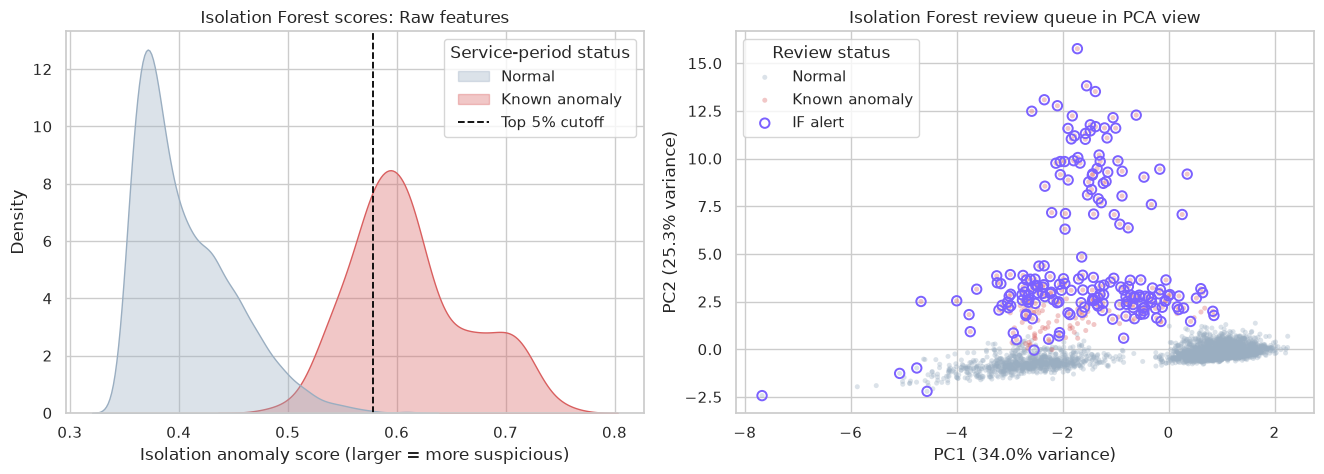

In [5]:
# Section focus: Discussion.
# The code groups setup, estimation, and diagnostics so the output can be rerun reproducibly.

recommended_name = model_table.sort_values(['average_precision', 'precision'], ascending=False).iloc[0]['detector']
recommended = fitted_models[recommended_name]
ops_df['iforest_score'] = recommended['score']
ops_df['iforest_alert'] = recommended['alert']
iforest_cutoff = recommended['cutoff']
X_recommended = recommended['X']
display_names = recommended['display_names']
iforest_model = recommended['model']

fig, axes = plt.subplots(1, 2, figsize=(13.4, 4.9))

sns.kdeplot(
    data=ops_df,
    x='iforest_score',
    hue='known_anomaly',
    fill=True,
    common_norm=False,
    alpha=0.35,
    palette={0: PALETTE['normal_web'], 1: PALETTE['memory_leak']},
    ax=axes[0],
)
axes[0].axvline(iforest_cutoff, color='black', linestyle='--', linewidth=1.3)
axes[0].set_title(f'Isolation Forest scores: {recommended_name}')
axes[0].set_xlabel('Isolation anomaly score (larger = more suspicious)')
axes[0].set_ylabel('Density')
axes[0].legend(
    handles=[
        Patch(facecolor=PALETTE['normal_web'], edgecolor=PALETTE['normal_web'], alpha=0.35, label='Normal'),
        Patch(facecolor=PALETTE['memory_leak'], edgecolor=PALETTE['memory_leak'], alpha=0.35, label='Known anomaly'),
        Line2D([0], [0], color='black', linestyle='--', linewidth=1.3, label='Top 5% cutoff'),
    ],
    title='Service-period status',
    frameon=True,
)

for known, label, color in [(0, 'Normal', PALETTE['normal_web']), (1, 'Known anomaly', PALETTE['memory_leak'])]:
    subset = ops_df[ops_df['known_anomaly'].eq(known)]
    axes[1].scatter(subset['pc1'], subset['pc2'], s=13, alpha=0.35, color=color, label=label, edgecolor='none')
alert_subset = ops_df[ops_df['iforest_alert']]
axes[1].scatter(
    alert_subset['pc1'], alert_subset['pc2'],
    s=46, facecolors='none', edgecolors=PALETTE['alert'], linewidths=1.4, label='IF alert'
)
axes[1].set_title('Isolation Forest review queue in PCA view')
axes[1].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%} variance)')
axes[1].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%} variance)')
axes[1].legend(title='Review status', frameon=True, loc='best')

plt.tight_layout()
plt.show()

The score distribution is useful because it shows whether the top review queue is separated from ordinary operation or whether it sits in a wide region of overlap. The PCA alert plot is a second audit: it shows whether the review queue is concentrated in plausible failure regions or in a normal operating mode.

The PCA plot is not the model. It is a visual diagnostic of a high-dimensional tree-based score.

## 6. Review Budget Sensitivity

Isolation Forest gives a ranking. The review budget converts that ranking into an action.

For a review budget $q$, define the threshold

$$
\tau_q = \operatorname{Quantile}_{1-q}(S_1,\ldots,S_n).
$$

Then alert when

$$
A_i(q) = \mathbb{1}\{S_i \ge \tau_q\}.
$$

Changing $q$ is not a technical afterthought. It changes workload, precision, recall, and escalation risk.

,review_budget,cutoff,alerts,alert_rate,precision,recall,false_positive_rate,false_alerts,normal_batch_share_of_false_alerts,workload_hours
0,2%,0.627,79,2.0%,100.0%,30.4%,0.00%,0,0.0%,52.2
1,3%,0.609,118,3.0%,99.2%,45.0%,0.03%,1,100.0%,77.0
2,5%,0.578,196,5.0%,97.4%,73.5%,0.14%,5,100.0%,123.3
3,8%,0.524,313,8.0%,82.1%,98.8%,1.53%,56,94.6%,174.5
4,12%,0.488,470,12.0%,55.3%,100.0%,5.75%,210,87.6%,209.2


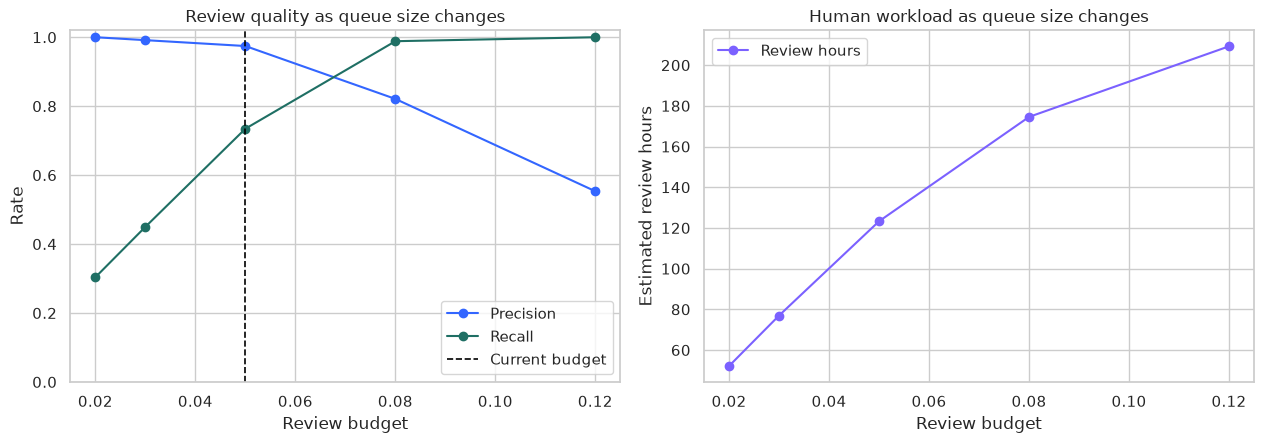

In [6]:
# Section focus: 6. Review Budget Sensitivity.
# The code groups setup, estimation, and diagnostics so the output can be rerun reproducibly.

budget_rows = []
for budget in [0.02, 0.03, 0.05, 0.08, 0.12]:
    cutoff = np.quantile(ops_df['iforest_score'], 1 - budget)
    alert = ops_df['iforest_score'] >= cutoff
    row = evaluate_alerts(ops_df['iforest_score'], alert, f'Top {budget:.0%}')
    row['review_budget'] = budget
    row['cutoff'] = cutoff
    budget_rows.append(row)

budget_table = pd.DataFrame(budget_rows)
smart_display(budget_table[[
    'review_budget', 'cutoff', 'alerts', 'alert_rate', 'precision', 'recall',
    'false_positive_rate', 'false_alerts', 'normal_batch_share_of_false_alerts', 'workload_hours'
]].style.format({
    'review_budget': '{:.0%}',
    'cutoff': '{:.3f}',
    'alert_rate': '{:.1%}',
    'precision': '{:.1%}',
    'recall': '{:.1%}',
    'false_positive_rate': '{:.2%}',
    'normal_batch_share_of_false_alerts': '{:.1%}',
    'workload_hours': '{:.1f}',
}))

fig, axes = plt.subplots(1, 2, figsize=(12.8, 4.6))
axes[0].plot(budget_table['review_budget'], budget_table['precision'], marker='o', label='Precision', color='#3366ff')
axes[0].plot(budget_table['review_budget'], budget_table['recall'], marker='o', label='Recall', color=PALETTE['decision'])
axes[0].axvline(review_budget, color='black', linestyle='--', linewidth=1.2, label='Current budget')
axes[0].set_title('Review quality as queue size changes')
axes[0].set_xlabel('Review budget')
axes[0].set_ylabel('Rate')
axes[0].set_ylim(0, 1.02)
axes[0].legend(frameon=True)

axes[1].plot(budget_table['review_budget'], budget_table['workload_hours'], marker='o', color=PALETTE['alert'], label='Review hours')
axes[1].set_title('Human workload as queue size changes')
axes[1].set_xlabel('Review budget')
axes[1].set_ylabel('Estimated review hours')
axes[1].legend(frameon=True)
plt.tight_layout()
plt.show()

The review budget is a policy lever. A narrow queue usually has higher precision but misses more true incidents. A wider queue catches more incidents but consumes more analyst time and produces more false positives. The table reports both the false-positive rate and the raw false-alert count because rare false alerts can round to `0.00%` while still mattering operationally.

For decision systems, the goal is to choose an operating point that matches staffing, risk tolerance, and the cost of missed incidents.

## 7. Subsampling and Tree Count Sensitivity

Isolation Forest has two important modeling controls:

| Parameter | Meaning | Practical effect |
|---|---|---|
| `max_samples` | Number of rows used to build each tree | Controls the scale of isolation patterns |
| `n_estimators` | Number of isolation trees | Reduces Monte Carlo variability |

The original Isolation Forest work emphasizes subsampling as a strength: small subsamples can isolate anomalies efficiently. In production, however, we should still check whether the recommendation is stable across plausible values.

,max_samples,n_estimators,precision,recall,average_precision,roc_auc,normal_batch_share_of_false_alerts,workload_hours
0,128,100,94.9%,71.5%,95.8%,0.997,100.0%,120.5
1,128,200,94.4%,71.2%,95.6%,0.997,100.0%,120.9
2,128,400,96.4%,72.7%,96.1%,0.997,100.0%,122.7
3,256,100,98.0%,73.8%,98.1%,0.999,100.0%,124.3
4,256,200,96.4%,72.7%,96.8%,0.998,100.0%,122.8
5,256,400,96.4%,72.7%,96.3%,0.997,100.0%,122.3
6,512,100,94.4%,71.2%,95.2%,0.997,100.0%,121.3
7,512,200,93.9%,70.8%,94.9%,0.996,100.0%,120.3
8,512,400,93.4%,70.4%,95.4%,0.997,100.0%,120.1
9,1024,100,92.9%,70.0%,95.2%,0.997,92.9%,119.8


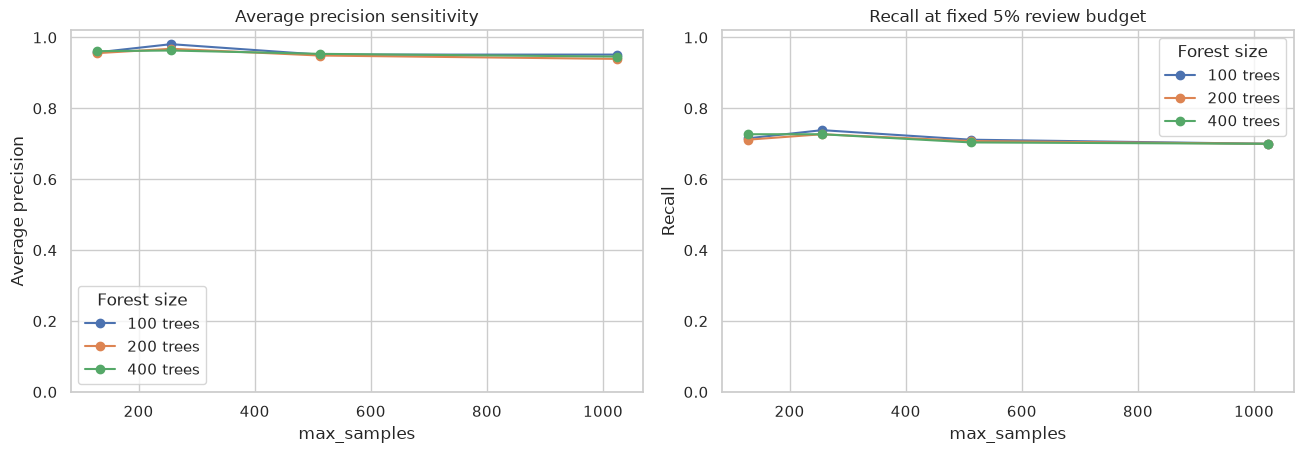

In [7]:
# Section focus: 7. Subsampling and Tree Count Sensitivity.
# The code groups setup, estimation, and diagnostics so the output can be rerun reproducibly.

sensitivity_rows = []
for max_samples in [128, 256, 512, 1024]:
    for n_estimators in [100, 200, 400]:
        model, score = fit_isolation_forest(
            X_raw if recommended_name == 'Raw features' else X_log,
            contamination=review_budget,
            max_samples=max_samples,
            n_estimators=n_estimators,
            random_state=RANDOM_SEED,
        )
        cutoff = np.quantile(score, 1 - review_budget)
        alert = score >= cutoff
        row = evaluate_alerts(score, alert, f'max_samples={max_samples}, trees={n_estimators}')
        row['max_samples'] = max_samples
        row['n_estimators'] = n_estimators
        sensitivity_rows.append(row)

sensitivity_table = pd.DataFrame(sensitivity_rows)
smart_display(sensitivity_table[[
    'max_samples', 'n_estimators', 'precision', 'recall', 'average_precision',
    'roc_auc', 'normal_batch_share_of_false_alerts', 'workload_hours'
]].style.format({
    'precision': '{:.1%}',
    'recall': '{:.1%}',
    'average_precision': '{:.1%}',
    'roc_auc': '{:.3f}',
    'normal_batch_share_of_false_alerts': '{:.1%}',
    'workload_hours': '{:.1f}',
}))

fig, axes = plt.subplots(1, 2, figsize=(13.2, 4.7))
for n_estimators, subset in sensitivity_table.groupby('n_estimators'):
    axes[0].plot(subset['max_samples'], subset['average_precision'], marker='o', label=f'{n_estimators} trees')
    axes[1].plot(subset['max_samples'], subset['recall'], marker='o', label=f'{n_estimators} trees')
axes[0].set_title('Average precision sensitivity')
axes[0].set_xlabel('max_samples')
axes[0].set_ylabel('Average precision')
axes[0].set_ylim(0, 1.02)
axes[0].legend(title='Forest size', frameon=True)
axes[1].set_title('Recall at fixed 5% review budget')
axes[1].set_xlabel('max_samples')
axes[1].set_ylabel('Recall')
axes[1].set_ylim(0, 1.02)
axes[1].legend(title='Forest size', frameon=True)
plt.tight_layout()
plt.show()

A stable detector does not require one exact hyperparameter setting to work. If performance collapses when `max_samples` or the tree count changes slightly, the team should be cautious.

The sensitivity table also helps distinguish ranking quality from operating performance. `average_precision` evaluates the full ranking. Recall at a fixed review budget evaluates the launch rule.

## 8. Feature Diagnostics for Isolation Scores

Isolation Forest is not naturally explainable in the same way as a supervised decision tree. We can still build practical diagnostics.

We will use two complementary summaries:

1. **Split frequency:** how often each feature is used in tree splits. This is not causal importance, but it shows what the random forest is partitioning on.
2. **Median replacement score drop:** for alerted cases, replace one feature at a time with its normal median and measure how much the anomaly score falls.

The second diagnostic is closer to reviewer language: *which feature changes would make these alerts look less unusual?*

,feature,split_frequency,mean_score_drop_when_replaced_by_normal_median,median_score_drop_when_replaced_by_normal_median
0,Memory (%),13.7%,0.0156,0.0115
1,Error Rate (%),13.4%,0.0434,0.0416
2,P95 Latency (ms),13.3%,0.0274,0.0233
3,Request Rate,13.3%,0.0030,0.0011
4,Network Out (MB/s),13.2%,0.0251,0.0057
5,CPU (%),13.1%,0.0093,0.0072
6,Disk IO (MB/s),13.0%,0.0060,0.0023
7,Restart Count,7.0%,0.0300,0.0193


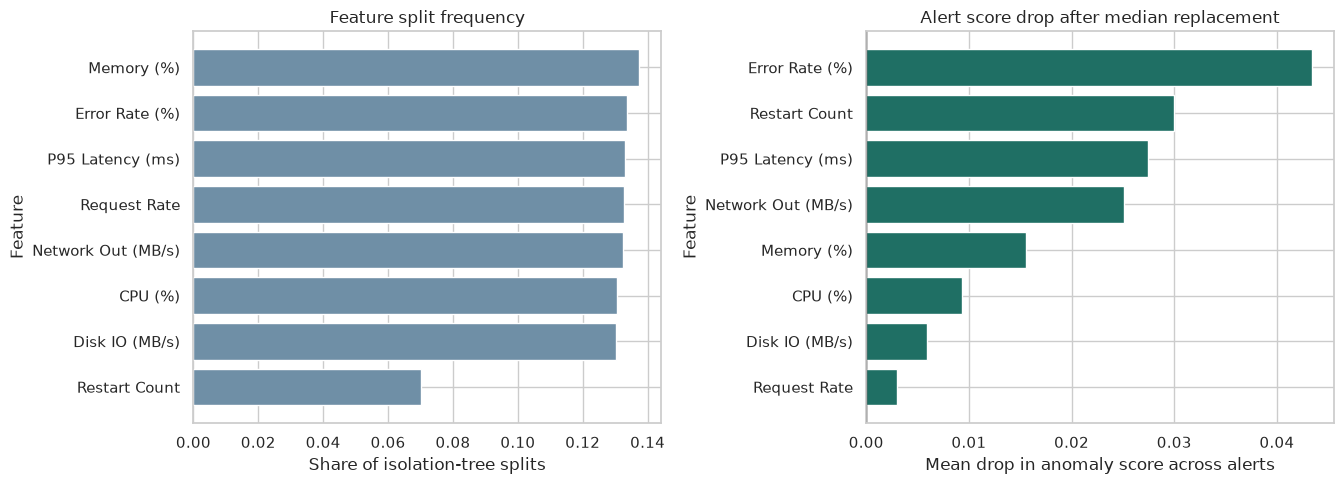

In [8]:
# Section focus: 8. Feature Diagnostics for Isolation Scores.
# The code groups setup, estimation, and diagnostics so the output can be rerun reproducibly.

def split_frequency(model, feature_names):
    """Carry out the split frequency step used in the 07. Tree-Based Anomaly Detection: Isolation Forest workflow.
    
    Parameters
    ----------
    model : object
        Fitted model or model specification used by this step.
    feature_names : object
        Column or variable name used to select information from the input table.
    
    Returns
    -------
    object
        Intermediate result produced by the split frequency calculation and reused by later cells.
    """
    counts = pd.Series(0, index=feature_names, dtype=float)
    total = 0
    for estimator in model.estimators_:
        split_features = estimator.tree_.feature
        split_features = split_features[split_features >= 0]
        total += len(split_features)
        for idx in split_features:
            counts.iloc[idx] += 1
    return (counts / total).sort_values(ascending=False)

split_freq = split_frequency(iforest_model, X_recommended.columns)

alert_indices = ops_df.index[ops_df['iforest_alert']]
normal_medians = X_recommended.loc[ops_df['known_anomaly'].eq(0)].median()
base_alert_scores = ops_df.loc[alert_indices, 'iforest_score'].to_numpy()
replacement_rows = []
for feature in X_recommended.columns:
    modified = X_recommended.loc[alert_indices].copy()
    modified[feature] = normal_medians[feature]
    modified_score = -iforest_model.score_samples(modified)
    replacement_rows.append({
        'feature': display_names.get(feature, feature),
        'mean_score_drop_when_replaced_by_normal_median': float(np.mean(base_alert_scores - modified_score)),
        'median_score_drop_when_replaced_by_normal_median': float(np.median(base_alert_scores - modified_score)),
    })
replacement_table = pd.DataFrame(replacement_rows).sort_values(
    'mean_score_drop_when_replaced_by_normal_median', ascending=False
)

feature_diag = pd.DataFrame({
    'feature': [display_names.get(feature, feature) for feature in split_freq.index],
    'split_frequency': split_freq.to_numpy(),
}).merge(replacement_table, on='feature', how='left')

smart_display(feature_diag.style.format({
    'split_frequency': '{:.1%}',
    'mean_score_drop_when_replaced_by_normal_median': '{:.4f}',
    'median_score_drop_when_replaced_by_normal_median': '{:.4f}',
}))

fig, axes = plt.subplots(1, 2, figsize=(13.6, 5.0))
plot_split = feature_diag.sort_values('split_frequency')
axes[0].barh(plot_split['feature'], plot_split['split_frequency'], color='#6f8fa6')
axes[0].set_title('Feature split frequency')
axes[0].set_xlabel('Share of isolation-tree splits')
axes[0].set_ylabel('Feature')

plot_drop = replacement_table.sort_values('mean_score_drop_when_replaced_by_normal_median')
axes[1].barh(plot_drop['feature'], plot_drop['mean_score_drop_when_replaced_by_normal_median'], color=PALETTE['decision'])
axes[1].axvline(0, color='black', linewidth=1)
axes[1].set_title('Alert score drop after median replacement')
axes[1].set_xlabel('Mean drop in anomaly score across alerts')
axes[1].set_ylabel('Feature')
plt.tight_layout()
plt.show()

Split frequency and score-drop diagnostics answer different questions. Split frequency is a model-structure diagnostic. Score-drop analysis is closer to an alert explanation.

Neither should be interpreted causally. If replacing `error_rate_pct` reduces the score, that does not prove errors caused the incident. It means the model treats the observed error rate as part of why the case is easy to isolate.

## 9. Explaining a Selected Alert

For analyst review, a single alert should be accompanied by local context. We select a high-scoring true anomaly when one exists, then compare it with its nearest normal neighbors in the recommended feature representation.

The explanation includes:

1. the selected case's raw feature values,
2. nearest-normal-neighbor means, and
3. standardized gaps relative to the neighbor group.

,feature,case_value,neighbor_mean,neighbor_standardized_gap
5,Error Rate (%),9.18,0.22,55.21
6,Restart Count,10.00,0.17,25.94
4,P95 Latency (ms),579.02,380.18,5.00
0,CPU (%),23.04,72.46,-4.89
7,Request Rate,506.84,324.83,3.40
1,Memory (%),36.22,67.50,-3.11
2,Disk IO (MB/s),28.18,157.39,-2.88
3,Network Out (MB/s),38.40,50.17,-0.51


,Quantity,Value
0,Selected case id,3841
1,Known label,1
2,Regime,crash_loop
3,Isolation score,0.750
4,Top 5% cutoff,0.578
5,Nearest-neighbor normal batch share,96.7%


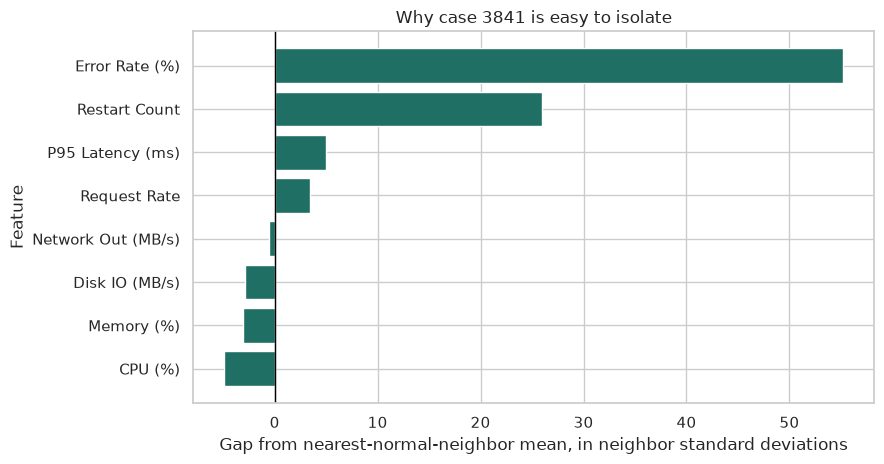

In [9]:
# Section focus: 9. Explaining a Selected Alert.
# The code groups setup, estimation, and diagnostics so the output can be rerun reproducibly.

alert_pool = ops_df[ops_df['iforest_alert']].copy()
true_alert_pool = alert_pool[alert_pool['known_anomaly'].eq(1)]
selected_idx = (true_alert_pool if len(true_alert_pool) else alert_pool).sort_values('iforest_score', ascending=False).index[0]
selected = ops_df.loc[selected_idx]

normal_mask = ops_df['known_anomaly'].eq(0)
nn = NearestNeighbors(n_neighbors=30)
nn.fit(X_recommended.loc[normal_mask])
normal_indices = ops_df.index[normal_mask].to_numpy()
distances, neighbor_positions = nn.kneighbors(X_recommended.loc[[selected_idx]])
neighbor_idx = normal_indices[neighbor_positions[0]]
neighbors = ops_df.loc[neighbor_idx]

neighbor_mean = neighbors[feature_cols].mean()
neighbor_sd = neighbors[feature_cols].std().replace(0, np.nan)
raw_gap = (selected[feature_cols].astype(float) - neighbor_mean) / neighbor_sd

local_explanation = pd.DataFrame({
    'feature': [raw_display_names[col] for col in feature_cols],
    'case_value': selected[feature_cols].astype(float).to_numpy(),
    'neighbor_mean': neighbor_mean.to_numpy(dtype=float),
    'neighbor_standardized_gap': raw_gap.to_numpy(dtype=float),
}).sort_values('neighbor_standardized_gap', key=lambda s: s.abs(), ascending=False)

case_summary = pd.DataFrame({
    'Quantity': [
        'Selected case id',
        'Known label',
        'Regime',
        'Isolation score',
        'Top 5% cutoff',
        'Nearest-neighbor normal batch share',
    ],
    'Value': [
        str(selected_idx),
        str(int(selected['known_anomaly'])),
        str(selected['regime']),
        f'{selected["iforest_score"]:.3f}',
        f'{iforest_cutoff:.3f}',
        f'{neighbors["regime"].eq("normal_batch").mean():.1%}',
    ],
})

smart_display(local_explanation.style.format({
    'case_value': '{:.2f}',
    'neighbor_mean': '{:.2f}',
    'neighbor_standardized_gap': '{:.2f}',
}))
smart_display(case_summary)

fig, ax = plt.subplots(figsize=(9.0, 4.8))
plot_data = local_explanation.sort_values('neighbor_standardized_gap')
ax.barh(plot_data['feature'], plot_data['neighbor_standardized_gap'], color=PALETTE['decision'])
ax.axvline(0, color='black', linewidth=1)
ax.set_title(f'Why case {selected_idx} is easy to isolate')
ax.set_xlabel('Gap from nearest-normal-neighbor mean, in neighbor standard deviations')
ax.set_ylabel('Feature')
plt.tight_layout()
plt.show()

The local explanation converts a tree-based score into operational evidence. The analyst can see whether the case is isolated because of restarts, latency, memory, network output, or a combination.

Very large standardized gaps can occur when the selected case is extreme on a feature whose nearest normal neighbors have little local variation. That can be a real diagnostic signal to inspect the raw value, the neighbor mean, and the neighbor spread together.

The nearest-neighbor batch share is also useful. If an alert's nearest normal neighbors are mostly batch jobs, the team should be careful not to misclassify legitimate batch behavior as an incident.

## 10. Decision Memo

The launch memo should translate Isolation Forest from model output into an operating procedure. It should state the recommended score, review threshold, expected workload, known false-alert risks, and monitoring plan.

In [10]:
# Section focus: 10. Decision Memo.
# The code groups setup, estimation, and diagnostics so the output can be rerun reproducibly.

recommended_metrics = model_table[model_table['detector'].eq(recommended_name)].iloc[0]
current_budget_metrics = budget_table[budget_table['review_budget'].eq(review_budget)].iloc[0]

memo = pd.DataFrame({
    'Memo item': [
        'Recommended launch score',
        'Operating threshold',
        'Expected queue size',
        'Expected precision and recall',
        'Representation choice',
        'Main false-alert risk',
        'Monitoring plan',
        'Human-review instruction',
    ],
    'Decision note': [
        f'Use Isolation Forest anomaly score from the {recommended_name.lower()} representation as the first-pass ranked score.',
        f'Flag the top {review_budget:.0%} of service periods; current cutoff is {iforest_cutoff:.3f}.',
        f'Expected alert rate is {current_budget_metrics["alert_rate"]:.1%}, or {int(current_budget_metrics["alerts"])} cases in this batch, requiring about {current_budget_metrics["workload_hours"]:.1f} review hours.',
        f'Estimated precision is {current_budget_metrics["precision"]:.1%}; estimated recall is {current_budget_metrics["recall"]:.1%} using synthetic known labels.',
        f'The {recommended_name.lower()} representation performed best here; do not assume log transforms improve tree-based isolation without checking alert quality.',
        'Legitimate batch jobs can be structurally different from web traffic; monitor false alerts by service type before automating escalation.',
        'Track alert volume, confirmed precision, score drift, false alerts by regime, and sensitivity to max_samples and review budget.',
        'Show nearest-neighbor feature gaps and score-drop diagnostics with each alert so reviewers can distinguish incident evidence from ordinary rarity.',
    ],
})

smart_display(memo)

,Memo item,Decision note
0,Recommended launch score,Use Isolation Forest anomaly score from the raw features representation as the first-pass ranked score.
1,Operating threshold,Flag the top 5% of service periods; current cutoff is 0.578.
2,Expected queue size,"Expected alert rate is 5.0%, or 196 cases in this batch, requiring about 123.3 review hours."
3,Expected precision and recall,Estimated precision is 97.4%; estimated recall is 73.5% using synthetic known labels.
4,Representation choice,The raw features representation performed best here; do not assume log transforms improve tree-based isolation without checking alert quality.
5,Main false-alert risk,Legitimate batch jobs can be structurally different from web traffic; monitor false alerts by service type before automating escalation.
6,Monitoring plan,"Track alert volume, confirmed precision, score drift, false alerts by regime, and sensitivity to max_samples and review budget."
7,Human-review instruction,Show nearest-neighbor feature gaps and score-drop diagnostics with each alert so reviewers can distinguish incident evidence from ordinary rarity.


In Decision Memo, the detector earns its keep only if the output sharpens the review queue.


## Key Takeaways

- Isolation Forest detects anomalies by measuring how quickly random tree splits isolate a case.
- Shorter average path length means a case is easier to isolate and therefore more suspicious.
- Isolation Forest is not a density estimator and does not require Euclidean distances.
- Tree-based methods are less sensitive to scaling than distance methods, but feature representation still matters.
- Review budget is a decision parameter: it controls workload, precision, and recall.
- `max_samples` and `n_estimators` should be stress-tested before launch.
- Feature diagnostics should be treated as model explanations, not causal explanations.
- Production use requires segment monitoring, human review, score drift checks, and feedback from confirmed incidents.

## References

Bandaragoda, T. R., Ting, K. M., Albrecht, D., Liu, F. T., Zhu, Y., & Wells, J. R. (2018). Isolation-based anomaly detection using nearest-neighbor ensembles. *Computational Intelligence, 34*(4), 968-998. [https://doi.org/10.1111/coin.12156](https://doi.org/10.1111/coin.12156)

Chandola, V., Banerjee, A., & Kumar, V. (2009). Anomaly detection. *ACM Computing Surveys, 41*(3), 1-58. [https://doi.org/10.1145/1541880.1541882](https://doi.org/10.1145/1541880.1541882)

Hariri, S., Carrasco Kind, M., & Brunner, R. J. (2021). Extended Isolation Forest. *IEEE Transactions on Knowledge and Data Engineering, 33*(4), 1479-1489. [https://doi.org/10.1109/TKDE.2019.2947676](https://doi.org/10.1109/TKDE.2019.2947676)

Liu, F. T., Ting, K. M., & Zhou, Z.-H. (2008). Isolation Forest. *2008 Eighth IEEE International Conference on Data Mining*, 413-422. [https://doi.org/10.1109/ICDM.2008.17](https://doi.org/10.1109/ICDM.2008.17)

Liu, F. T., Ting, K. M., & Zhou, Z.-H. (2012). Isolation-based anomaly detection. *ACM Transactions on Knowledge Discovery from Data, 6*(1), 1-39. [https://doi.org/10.1145/2133360.2133363](https://doi.org/10.1145/2133360.2133363)
